# Low-Resolution Advection-Band Diagnostic Sweep

Focused low-resolution x4 experiment for testing whether advection-band conditioning is useful as a diagnostic tool. The true longitudinal advection is -0.126, while the low-resolution longitude step is 0.252, so the physical one-step upstream location lies halfway between the same grid cell and the +1 east cell. This notebook separates physically aligned east offsets from farther directional east offsets and wrong-direction west controls.


In [1]:
import os
import sys
import time
import io
import contextlib
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.fft
import matplotlib.pyplot as plt

AMAREL_SRC = "/home/jl2815/tco"
LOCAL_SRC = "/Users/joonwonlee/Documents/GEMS_TCO-1/src"
_src = AMAREL_SRC if os.path.exists(AMAREL_SRC) else LOCAL_SRC
sys.path.insert(0, _src)

from GEMS_TCO import kernels_vecchia
from GEMS_TCO import kernels_vecchia_advec_band
from GEMS_TCO import orderings as _orderings

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float64

# Low-resolution stress test: same domain, 4x coarser in both lat/lon.
DELTA_LAT = 0.044 * 4
DELTA_LON = 0.063 * 4
T_STEPS = 8

print("DEVICE:", DEVICE)
print("SRC:", _src)
print("Grid resolution:", DELTA_LAT, DELTA_LON)


DEVICE: cpu
SRC: /Users/joonwonlee/Documents/GEMS_TCO-1/src
Grid resolution: 0.176 0.252


## Settings And Model Groups


In [2]:
LAT_RANGE = (-3.0, 2.0)
LON_RANGE = (121.0, 131.0)
MC_NUM_ITERS = 30
SEED = 42

SMOOTH = 0.5
MM_COND_NUMBER = 100
NHEADS = 0
DAILY_STRIDE = 2

LBFGS_STEPS = 5
LBFGS_EVAL = 20
LBFGS_HIST = 10
INIT_NOISE = 0.7
SUPPRESS_FIT_PRINTS = True

RUN_ONE_SHOT_GODAMBE = True
HESSIAN_EPS = 1e-4
SCORE_EPS = 1e-5
H_RIDGE_SCALE = 1e-6
GODAMBE_J_METHOD = "block"
GODAMBE_BLOCK_LAT_WIDTH = 0.50
GODAMBE_BLOCK_LON_WIDTH = 0.50
GODAMBE_BLOCK_TIME_WIDTH = 2.0

TRUE_DICT = {
    "sigmasq": 10.0,
    "range_lat": 0.30,
    "range_lon": 0.40,
    "range_time": 2.0,
    "advec_lat": 0.08,
    "advec_lon": -0.126,
    "nugget": 2.5,
}

TRUE_UPSTREAM_CELLS = abs(TRUE_DICT["advec_lon"]) / DELTA_LON
print(f"Low-res lon step = {DELTA_LON:.3f}; true one-step upstream = {TRUE_UPSTREAM_CELLS:.2f} cells east")

BASE_A = 12
BASE_B_TOTAL = 8
BASE_C = 6

def total_conditioning(a, b=0, c=0, uses_lag1=True, uses_lag2=True, n_advec=0):
    total = int(a)
    if uses_lag1:
        total += int(1 + b + n_advec)
    if uses_lag2:
        total += int(1 + c)
    return total

def std_spec(name, a, b, c, group, allocation, daily_stride=DAILY_STRIDE, uses_lag2=True):
    return {
        "name": name,
        "group": group,
        "kernel": "std",
        "limit_A": int(a),
        "limit_B": int(b),
        "limit_C": int(c),
        "daily_stride": int(daily_stride),
        "uses_lag2": bool(uses_lag2),
        "advec_cell_offsets": tuple(),
        "lon_resolution": DELTA_LON,
        "lag1_ratio_actual": float(b / a) if a else np.nan,
        "lag2_ratio_actual": float(c / a) if (a and uses_lag2) else 0.0,
        "total_conditioning": total_conditioning(a, b, c, uses_lag1=True, uses_lag2=uses_lag2),
        "allocation": allocation,
        "description": f"t: {a}; t-1: same loc + {b} local; t-2: same loc + {c} local",
    }

def advec_spec(name, a, b_local, c, group, allocation, cell_offsets):
    cell_offsets = tuple(int(v) for v in cell_offsets)
    return {
        "name": name,
        "group": group,
        "kernel": "advec_band",
        "limit_A": int(a),
        "limit_B": int(b_local),
        "limit_C": int(c),
        "daily_stride": DAILY_STRIDE,
        "uses_lag2": True,
        "advec_cell_offsets": cell_offsets,
        "lon_resolution": DELTA_LON,
        "lag1_ratio_actual": float((b_local + len(cell_offsets)) / a) if a else np.nan,
        "lag2_ratio_actual": float(c / a) if a else np.nan,
        "total_conditioning": total_conditioning(a, b_local, c, uses_lag1=True, uses_lag2=True, n_advec=len(cell_offsets)),
        "allocation": allocation,
        "description": f"t: {a}; t-1: same loc + {b_local} local + directional cells {cell_offsets}; t-2: same loc + {c} local",
    }

EXPERIMENT_GROUPS = {
    "advec_diagnostic_A12": [
        std_spec("BaseLocal_A12_B08_C06", BASE_A, BASE_B_TOTAL, BASE_C, "advec_diagnostic_A12", "base local lag-1"),
        advec_spec("PhysEast1_A12_B07p1_C06", BASE_A, BASE_B_TOTAL - 1, BASE_C, "advec_diagnostic_A12", "physical bracket: +1 east", (1,)),
        advec_spec("FarEast2_A12_B07p2_C06", BASE_A, BASE_B_TOTAL - 1, BASE_C, "advec_diagnostic_A12", "farther east: +2", (2,)),
        advec_spec("NearEast12_A12_B06p12_C06", BASE_A, BASE_B_TOTAL - 2, BASE_C, "advec_diagnostic_A12", "near/far east band: +1,+2", (1, 2)),
        advec_spec("FarEast23_A12_B06p23_C06", BASE_A, BASE_B_TOTAL - 2, BASE_C, "advec_diagnostic_A12", "far east band: +2,+3", (2, 3)),
        advec_spec("WrongWest1_A12_B07m1_C06", BASE_A, BASE_B_TOTAL - 1, BASE_C, "advec_diagnostic_A12", "wrong direction control: -1 west", (-1,)),
        advec_spec("WrongWest12_A12_B06m12_C06", BASE_A, BASE_B_TOTAL - 2, BASE_C, "advec_diagnostic_A12", "wrong direction control: -1,-2 west", (-1, -2)),
    ]
}

ACTIVE_GROUPS = ["advec_diagnostic_A12"]

MODEL_SPECS = {}
for group_name in ACTIVE_GROUPS:
    for spec in EXPERIMENT_GROUPS[group_name]:
        key = f"{group_name}::{spec['name']}"
        MODEL_SPECS[key] = spec

spec_df = pd.DataFrame(MODEL_SPECS).T
print("Active groups:", ACTIVE_GROUPS)
print("Number of model fits per MC iteration:", len(MODEL_SPECS))
display(spec_df[["group", "kernel", "limit_A", "limit_B", "limit_C", "advec_cell_offsets", "daily_stride", "allocation", "lag1_ratio_actual", "lag2_ratio_actual", "total_conditioning", "description"]])



Low-res lon step = 0.252; true one-step upstream = 0.50 cells east
Active groups: ['advec_diagnostic_A12']
Number of model fits per MC iteration: 7


,group,kernel,limit_A,limit_B,limit_C,advec_cell_offsets,daily_stride,allocation,lag1_ratio_actual,lag2_ratio_actual,total_conditioning,description
advec_diagnostic_A12::BaseLocal_A12_B08_C06,advec_diagnostic_A12,std,12,8,6,(),2,base local lag-1,0.666667,0.5,28,t: 12; t-1: same loc + 8 local; t-2: same loc ...
advec_diagnostic_A12::PhysEast1_A12_B07p1_C06,advec_diagnostic_A12,advec_band,12,7,6,"(1,)",2,physical bracket: +1 east,0.666667,0.5,28,t: 12; t-1: same loc + 7 local + directional c...
advec_diagnostic_A12::FarEast2_A12_B07p2_C06,advec_diagnostic_A12,advec_band,12,7,6,"(2,)",2,farther east: +2,0.666667,0.5,28,t: 12; t-1: same loc + 7 local + directional c...
advec_diagnostic_A12::NearEast12_A12_B06p12_C06,advec_diagnostic_A12,advec_band,12,6,6,"(1, 2)",2,"near/far east band: +1,+2",0.666667,0.5,28,t: 12; t-1: same loc + 6 local + directional c...
advec_diagnostic_A12::FarEast23_A12_B06p23_C06,advec_diagnostic_A12,advec_band,12,6,6,"(2, 3)",2,"far east band: +2,+3",0.666667,0.5,28,t: 12; t-1: same loc + 6 local + directional c...
advec_diagnostic_A12::WrongWest1_A12_B07m1_C06,advec_diagnostic_A12,advec_band,12,7,6,"(-1,)",2,wrong direction control: -1 west,0.666667,0.5,28,t: 12; t-1: same loc + 7 local + directional c...
advec_diagnostic_A12::WrongWest12_A12_B06m12_C06,advec_diagnostic_A12,advec_band,12,6,6,"(-1, -2)",2,"wrong direction control: -1,-2 west",0.666667,0.5,28,t: 12; t-1: same loc + 6 local + directional c...


## Simulation Helpers


In [3]:
P_LABELS = ["sigmasq", "range_lat", "range_lon", "range_time", "advec_lat", "advec_lon", "nugget"]
P_COLS = ["sigmasq_est", "range_lat_est", "range_lon_est", "range_t_est", "advec_lat_est", "advec_lon_est", "nugget_est"]
SPATIAL_KEYS = ["sigmasq", "range_lat", "range_lon"]
ADVECTION_KEYS = ["advec_lat", "advec_lon"]

def transform_log_phi_to_physical(p):
    phi1, phi2, phi3, phi4 = (torch.exp(p[i]) for i in range(4))
    rlon = 1.0 / phi2
    return torch.stack([
        phi1 / phi2,
        rlon / torch.sqrt(phi3),
        rlon,
        rlon / torch.sqrt(phi4),
        p[4],
        p[5],
        torch.exp(p[6]),
    ])

def get_covariance_on_grid(lx, ly, lt, params):
    params = torch.clamp(params, min=-15.0, max=15.0)
    phi1, phi2, phi3, phi4 = (torch.exp(params[i]) for i in range(4))
    u_lat = lx - params[4] * lt
    u_lon = ly - params[5] * lt
    dist = torch.sqrt(u_lat.pow(2) * phi3 + u_lon.pow(2) + lt.pow(2) * phi4 + 1e-8)
    return (phi1 / phi2) * torch.exp(-dist * phi2)

def build_target_grid(lat_range, lon_range):
    lat0, lat1 = float(min(lat_range)), float(max(lat_range))
    lon0, lon1 = float(min(lon_range)), float(max(lon_range))
    n_lat = int(np.floor((lat1 - lat0) / DELTA_LAT + 1e-9)) + 1
    n_lon = int(np.floor((lon1 - lon0) / DELTA_LON + 1e-9)) + 1
    lats = lat0 + torch.arange(n_lat, device=DEVICE, dtype=DTYPE) * DELTA_LAT
    lons = lon0 + torch.arange(n_lon, device=DEVICE, dtype=DTYPE) * DELTA_LON
    lats = torch.round(lats * 10000) / 10000
    lons = torch.round(lons * 10000) / 10000
    g_lat, g_lon = torch.meshgrid(lats, lons, indexing="ij")
    grid_coords = torch.stack([g_lat.flatten(), g_lon.flatten()], dim=1)
    return lats, lons, grid_coords

def grid_resolution_report(lats, lons):
    lat_d = torch.diff(lats).detach().cpu().numpy()
    lon_d = torch.diff(lons).detach().cpu().numpy()
    return {
        "lat_min_step": float(lat_d.min()) if len(lat_d) else np.nan,
        "lat_max_step": float(lat_d.max()) if len(lat_d) else np.nan,
        "lon_min_step": float(lon_d.min()) if len(lon_d) else np.nan,
        "lon_max_step": float(lon_d.max()) if len(lon_d) else np.nan,
        "lat_first_last": (float(lats[0]), float(lats[-1])),
        "lon_first_last": (float(lons[0]), float(lons[-1])),
    }

def generate_field_values(n_lat, n_lon, t_steps, params):
    cpu = torch.device("cpu")
    f32 = torch.float32
    px, py, pt = 2 * n_lat, 2 * n_lon, 2 * t_steps
    lx = torch.arange(px, device=cpu, dtype=f32) * DELTA_LAT
    lx[px // 2:] -= px * DELTA_LAT
    ly = torch.arange(py, device=cpu, dtype=f32) * DELTA_LON
    ly[py // 2:] -= py * DELTA_LON
    lt = torch.arange(pt, device=cpu, dtype=f32)
    lt[pt // 2:] -= pt
    params_cpu = params.cpu().float()
    Lx, Ly, Lt = torch.meshgrid(lx, ly, lt, indexing="ij")
    C = get_covariance_on_grid(Lx, Ly, Lt, params_cpu)
    S = torch.fft.fftn(C)
    S.real = torch.clamp(S.real, min=0)
    noise = torch.fft.fftn(torch.randn(px, py, pt, device=cpu, dtype=f32))
    field = torch.fft.ifftn(torch.sqrt(S.real) * noise).real[:n_lat, :n_lon, :t_steps]
    return field.to(device=DEVICE, dtype=DTYPE)

def assemble_reg_map(field, grid_coords, true_params, t_offset=21.0):
    nugget_std = torch.sqrt(torch.exp(true_params[6]))
    n_grid = grid_coords.shape[0]
    field_flat = field.reshape(n_grid, field.shape[-1])
    reg_map = {}
    for t_idx in range(field.shape[-1]):
        key = f"t{t_idx}"
        t_val = float(t_offset + t_idx)
        dummy = torch.zeros(7, device=DEVICE, dtype=DTYPE)
        if t_idx > 0:
            dummy[t_idx - 1] = 1.0
        rows = torch.zeros((n_grid, 11), device=DEVICE, dtype=DTYPE)
        rows[:, :2] = grid_coords
        rows[:, 2] = field_flat[:, t_idx] + torch.randn(n_grid, device=DEVICE, dtype=DTYPE) * nugget_std
        rows[:, 3] = t_val
        rows[:, 4:] = dummy.unsqueeze(0).expand(n_grid, -1)
        reg_map[key] = rows.detach()
    return reg_map

def compute_grid_ordering(grid_coords, mm_cond_number):
    coords_np = grid_coords.detach().cpu().numpy()
    ord_mm = _orderings.maxmin_cpp(coords_np)
    nns = _orderings.find_nns_l2(locs=coords_np[ord_mm], max_nn=mm_cond_number)
    return ord_mm, nns

def true_to_log_params(true_dict):
    phi2 = 1.0 / true_dict["range_lon"]
    phi1 = true_dict["sigmasq"] * phi2
    phi3 = (true_dict["range_lon"] / true_dict["range_lat"]) ** 2
    phi4 = (true_dict["range_lon"] / true_dict["range_time"]) ** 2
    return [np.log(phi1), np.log(phi2), np.log(phi3), np.log(phi4), true_dict["advec_lat"], true_dict["advec_lon"], np.log(true_dict["nugget"])]

def backmap_params(out_params):
    p = [x.item() if isinstance(x, torch.Tensor) else float(x) for x in out_params[:7]]
    phi2 = np.exp(p[1])
    phi3 = np.exp(p[2])
    phi4 = np.exp(p[3])
    rlon = 1.0 / phi2
    return {
        "sigmasq": np.exp(p[0]) / phi2,
        "range_lat": rlon / phi3 ** 0.5,
        "range_lon": rlon,
        "range_time": rlon / phi4 ** 0.5,
        "advec_lat": p[4],
        "advec_lon": p[5],
        "nugget": np.exp(p[6]),
    }

def rmsre_for_keys(est, true_dict, keys, zero_thresh=0.01):
    vals = []
    for key in keys:
        tv = true_dict[key]
        ev = est[key]
        if abs(tv) >= zero_thresh:
            vals.append(((ev - tv) / abs(tv)) ** 2)
        else:
            vals.append(abs(ev - tv) ** 2)
    return float(np.sqrt(np.mean(vals)))

def relative_se_summary(se_by_key, denom_dict, keys, zero_thresh=0.01):
    vals = []
    for key in keys:
        denom = abs(denom_dict[key])
        if denom >= zero_thresh:
            vals.append((se_by_key[key] / denom) ** 2)
        else:
            vals.append(se_by_key[key] ** 2)
    return float(np.sqrt(np.mean(vals)))

def calculate_metrics(out_params, true_dict):
    est = backmap_params(out_params)
    return {
        "overall_rmsre": rmsre_for_keys(est, true_dict, P_LABELS),
        "spatial_rmsre": rmsre_for_keys(est, true_dict, SPATIAL_KEYS),
        "range_time_re": abs(est["range_time"] - true_dict["range_time"]) / abs(true_dict["range_time"]),
        "advec_rmsre": rmsre_for_keys(est, true_dict, ADVECTION_KEYS),
        "nugget_re": abs(est["nugget"] - true_dict["nugget"]) / abs(true_dict["nugget"]),
        "est": est,
    }

def make_random_init(rng, true_log, init_noise):
    noisy = list(true_log)
    for i in [0, 1, 2, 3, 6]:
        noisy[i] = true_log[i] + rng.uniform(-init_noise, init_noise)
    for i in [4, 5]:
        scale = max(abs(true_log[i]), 0.05)
        noisy[i] = true_log[i] + rng.uniform(-2 * scale, 2 * scale)
    return noisy


## Optional Godambe Helpers


In [4]:
def finite_diff_hessian(nll_fn, p, eps=HESSIAN_EPS):
    n = p.shape[0]
    H = torch.zeros(n, n, device=p.device, dtype=p.dtype)
    for i in range(n):
        p_p = p.detach().clone(); p_m = p.detach().clone()
        p_p[i] += eps; p_m[i] -= eps
        p_p.requires_grad_(True); p_m.requires_grad_(True)
        g_p = torch.autograd.grad(nll_fn(p_p), p_p)[0].detach()
        g_m = torch.autograd.grad(nll_fn(p_m), p_m)[0].detach()
        H[i] = (g_p - g_m) / (2.0 * eps)
    return (H + H.T) / 2.0

def vecchia_per_unit_target_coords(model):
    chunks = []
    if model.Heads_data is not None and model.Heads_data.shape[0] > 0:
        chunks.append(model.Heads_data[:, [0, 1, 3]].to(dtype=DTYPE))
    for X_b in [model.X_A, model.X_AB, model.X_ABC]:
        if X_b is not None and X_b.shape[0] > 0:
            chunks.append(X_b[:, -1, :].to(dtype=DTYPE))
    if not chunks:
        return torch.empty((0, 3), device=DEVICE, dtype=DTYPE)
    return torch.cat(chunks, dim=0)

def make_block_ids(target_coords):
    lat = target_coords[:, 0]
    lon = target_coords[:, 1]
    tim = target_coords[:, 2]
    lat_id = torch.floor((lat - lat.min()) / GODAMBE_BLOCK_LAT_WIDTH).to(torch.long)
    lon_id = torch.floor((lon - lon.min()) / GODAMBE_BLOCK_LON_WIDTH).to(torch.long)
    if GODAMBE_BLOCK_TIME_WIDTH is None or GODAMBE_BLOCK_TIME_WIDTH <= 0:
        time_id = torch.zeros_like(lat_id)
    else:
        time_id = torch.floor((tim - tim.min()) / GODAMBE_BLOCK_TIME_WIDTH).to(torch.long)
    n_lon = int(lon_id.max().item()) + 1 if lon_id.numel() else 1
    n_time = int(time_id.max().item()) + 1 if time_id.numel() else 1
    raw_id = (lat_id * n_lon + lon_id) * n_time + time_id
    _, block_id = torch.unique(raw_id, sorted=True, return_inverse=True)
    return block_id

def score_cov_per_unit_centered(score_mat):
    n_units = score_mat.shape[1]
    score_mean = score_mat.mean(dim=1)
    score_centered = score_mat - score_mean.unsqueeze(1)
    if n_units > 1:
        return score_centered @ score_centered.T / (n_units * (n_units - 1))
    return score_mat @ score_mat.T / max(n_units ** 2, 1)

def score_cov_block_cluster(score_mat, target_coords):
    n_units = score_mat.shape[1]
    scores = score_mat.T.contiguous()
    block_id = make_block_ids(target_coords)
    n_blocks = int(block_id.max().item()) + 1 if block_id.numel() else 0
    block_scores = torch.zeros((n_blocks, scores.shape[1]), device=DEVICE, dtype=DTYPE)
    block_scores.index_add_(0, block_id, scores)
    if n_blocks > 1:
        centered = block_scores - block_scores.mean(dim=0, keepdim=True)
        J = centered.T @ centered * (n_blocks / (n_blocks - 1)) / (n_units ** 2)
    else:
        J = block_scores.T @ block_scores / max(n_units ** 2, 1)
    return J, n_blocks

def compute_vecchia_godambe(model, raw_params):
    p_hat = torch.tensor(raw_params[:7], device=DEVICE, dtype=DTYPE, requires_grad=True)

    def nll(p):
        return model.vecchia_batched_likelihood(p)

    H = finite_diff_hessian(nll, p_hat)
    eig = torch.linalg.eigvalsh(H).detach()
    h_abs_min = torch.clamp(torch.min(torch.abs(eig)), min=1e-12)
    h_cond = float((torch.max(torch.abs(eig)) / h_abs_min).detach().cpu())
    beta_hat = model.get_gls_beta(p_hat).detach()

    def per_unit_losses(p):
        return model.vecchia_per_unit_nll_terms(p, beta_hat)

    cols = []
    for k in range(p_hat.shape[0]):
        pp = p_hat.detach().clone(); pm = p_hat.detach().clone()
        pp[k] += SCORE_EPS; pm[k] -= SCORE_EPS
        with torch.no_grad():
            cols.append((per_unit_losses(pp) - per_unit_losses(pm)) / (2.0 * SCORE_EPS))
    score_mat = torch.stack(cols)
    n_units = score_mat.shape[1]
    target_coords = vecchia_per_unit_target_coords(model)
    if target_coords.shape[0] != n_units:
        raise RuntimeError(f"target/score mismatch: targets={target_coords.shape[0]}, scores={n_units}")

    score_mean = score_mat.mean(dim=1)
    p_grad = p_hat.detach().clone().requires_grad_(True)
    profile_grad = torch.autograd.grad(nll(p_grad), p_grad)[0].detach()
    score_grad_diff = profile_grad - score_mean

    J_uncentered = score_mat @ score_mat.T / (n_units ** 2)
    J_centered = score_cov_per_unit_centered(score_mat)
    J_block, n_blocks = score_cov_block_cluster(score_mat, target_coords)
    if GODAMBE_J_METHOD == "block":
        J_main = J_block
    elif GODAMBE_J_METHOD == "per_unit_centered":
        J_main = J_centered
    elif GODAMBE_J_METHOD == "per_unit_uncentered":
        J_main = J_uncentered
    else:
        raise ValueError(f"Unknown GODAMBE_J_METHOD={GODAMBE_J_METHOD!r}")

    eye = torch.eye(H.shape[0], device=DEVICE, dtype=DTYPE)
    h_scale = torch.clamp(torch.mean(torch.abs(torch.diag(H))), min=1.0)
    H_inv = torch.linalg.pinv(H + eye * h_scale * H_RIDGE_SCALE)
    Jac = torch.autograd.functional.jacobian(transform_log_phi_to_physical, p_hat)

    def summarize_J(J):
        G_raw = H_inv @ J @ H_inv
        G_phys = Jac @ G_raw @ Jac.T
        se = torch.sqrt(torch.clamp(torch.diag(G_phys), min=0.0)).detach().cpu().numpy()
        se_by_key = dict(zip(P_LABELS, [float(x) for x in se]))
        return se_by_key, {
            "spatial": relative_se_summary(se_by_key, TRUE_DICT, SPATIAL_KEYS),
            "overall": relative_se_summary(se_by_key, TRUE_DICT, P_LABELS),
            "advec": relative_se_summary(se_by_key, TRUE_DICT, ADVECTION_KEYS),
            "nugget": se_by_key["nugget"] / abs(TRUE_DICT["nugget"]),
        }

    se_main, rel_main = summarize_J(J_main)
    se_block, rel_block = summarize_J(J_block)
    se_centered, rel_centered = summarize_J(J_centered)
    se_uncentered, rel_uncentered = summarize_J(J_uncentered)
    return {
        "gim_j_method": GODAMBE_J_METHOD,
        "gim_n_units": int(n_units),
        "gim_n_blocks": int(n_blocks),
        "gim_h_cond_abs": h_cond,
        "gim_score_mean_max_abs": float(torch.max(torch.abs(score_mean)).detach().cpu()),
        "gim_profile_grad_max_abs": float(torch.max(torch.abs(profile_grad)).detach().cpu()),
        "gim_score_profile_diff_max_abs": float(torch.max(torch.abs(score_grad_diff)).detach().cpu()),
        "gim_spatial_rel_se": rel_main["spatial"],
        "gim_overall_rel_se": rel_main["overall"],
        "gim_advec_rel_se": rel_main["advec"],
        "gim_nugget_rel_se": rel_main["nugget"],
        "gim_spatial_rel_se_block": rel_block["spatial"],
        "gim_spatial_rel_se_perunit_centered": rel_centered["spatial"],
        "gim_spatial_rel_se_uncentered": rel_uncentered["spatial"],
        **{f"gim_se_{k}": v for k, v in se_main.items()},
    }


## Fit And Monte Carlo


In [5]:
def fit_vecchia_spec(model_key, spec, reg_map_ord, nns_grid, ordered_grid_coords_np, initial_vals, compute_godambe=False):
    params = [torch.tensor([val], device=DEVICE, dtype=DTYPE, requires_grad=True) for val in initial_vals]
    daily_stride = int(spec.get("daily_stride", DAILY_STRIDE))
    if spec["kernel"] == "std":
        model = kernels_vecchia.fit_vecchia_lbfgs(
            smooth=SMOOTH,
            input_map=reg_map_ord,
            nns_map=nns_grid,
            mm_cond_number=MM_COND_NUMBER,
            nheads=NHEADS,
            limit_A=spec["limit_A"],
            limit_B=spec["limit_B"],
            limit_C=spec["limit_C"],
            daily_stride=daily_stride,
        )
    elif spec["kernel"] == "advec_band":
        model = kernels_vecchia_advec_band.fit_vecchia_lbfgs_advec_band(
            smooth=SMOOTH,
            input_map=reg_map_ord,
            nns_map=nns_grid,
            mm_cond_number=MM_COND_NUMBER,
            nheads=NHEADS,
            limit_A=spec["limit_A"],
            limit_B=spec["limit_B"],
            limit_C=spec["limit_C"],
            daily_stride=daily_stride,
            spatial_coords=ordered_grid_coords_np,
            lon_resolution=spec.get("lon_resolution", DELTA_LON),
            advec_cell_offsets=spec.get("advec_cell_offsets", (2, 3)),
        )
    else:
        raise ValueError(f"Unknown kernel: {spec['kernel']}")

    t0 = time.time()
    if SUPPRESS_FIT_PRINTS:
        with contextlib.redirect_stdout(io.StringIO()):
            model.precompute_conditioning_sets()
    else:
        model.precompute_conditioning_sets()
    precompute_s = time.time() - t0

    optimizer = model.set_optimizer(params, lr=1.0, max_iter=LBFGS_EVAL, history_size=LBFGS_HIST)
    t1 = time.time()
    if SUPPRESS_FIT_PRINTS:
        with contextlib.redirect_stdout(io.StringIO()):
            out, n_iter = model.fit_vecc_lbfgs(params, optimizer, max_steps=LBFGS_STEPS, grad_tol=1e-5)
    else:
        out, n_iter = model.fit_vecc_lbfgs(params, optimizer, max_steps=LBFGS_STEPS, grad_tol=1e-5)
    fit_s = time.time() - t1

    metrics = calculate_metrics(out, TRUE_DICT)
    godambe = {}
    gim_s = 0.0
    if compute_godambe:
        t2 = time.time()
        godambe = compute_vecchia_godambe(model, [float(x) for x in out[:7]])
        gim_s = time.time() - t2
    return out, float(out[-1]), int(n_iter), precompute_s, fit_s, gim_s, metrics, godambe

def run_experiment(num_iters=MC_NUM_ITERS, seed=SEED, compute_godambe=False, save_csv=True, csv_name=None):
    rng = np.random.default_rng(seed)
    torch.manual_seed(seed)
    true_log = true_to_log_params(TRUE_DICT)
    true_params = torch.tensor(true_log, device=DEVICE, dtype=DTYPE)
    lats_grid, lons_grid, grid_coords = build_target_grid(LAT_RANGE, LON_RANGE)
    n_lat, n_lon = len(lats_grid), len(lons_grid)
    print(f"Grid: {n_lat} x {n_lon} x {T_STEPS} = {n_lat * n_lon * T_STEPS:,} rows")
    print("Actual resolution:", grid_resolution_report(lats_grid, lons_grid))
    print("Model specs:")
    display(pd.DataFrame(MODEL_SPECS).T[["group", "kernel", "limit_A", "limit_B", "limit_C", "daily_stride", "uses_lag2", "allocation", "total_conditioning", "description"]])
    ord_grid, nns_grid = compute_grid_ordering(grid_coords, MM_COND_NUMBER)
    ordered_grid_coords_np = grid_coords[ord_grid].detach().cpu().numpy()
    print("Ordering done")

    records = []
    for it in range(num_iters):
        print(f"\n=== Iteration {it + 1}/{num_iters} ===")
        initial_vals = make_random_init(rng, true_log, INIT_NOISE)
        field = generate_field_values(n_lat, n_lon, T_STEPS, true_params)
        reg_map = assemble_reg_map(field, grid_coords, true_params)
        del field
        reg_map_ord = {k: v[ord_grid] for k, v in reg_map.items()}
        for model_key, spec in MODEL_SPECS.items():
            try:
                print(f"{model_key}: fitting", end="")
                out, loss, n_iter, pre_s, fit_s, gim_s, metrics, godambe = fit_vecchia_spec(
                    model_key, spec, reg_map_ord, nns_grid, ordered_grid_coords_np, initial_vals, compute_godambe=compute_godambe
                )
                est = metrics.pop("est")
                row = {
                    "iter": it + 1,
                    "model_key": model_key,
                    "model": spec["name"],
                    "group": spec["group"],
                    "kernel": spec["kernel"],
                    "allocation": spec["allocation"],
                    "limit_A": spec["limit_A"],
                    "limit_B": spec["limit_B"],
                    "limit_C": spec["limit_C"],
                    "daily_stride": spec.get("daily_stride", DAILY_STRIDE),
                    "uses_lag2": spec.get("uses_lag2", True),
                    "advec_cell_offsets": ",".join(map(str, spec.get("advec_cell_offsets", ()))),
                    "lag1_ratio_actual": spec["lag1_ratio_actual"],
                    "lag2_ratio_actual": spec["lag2_ratio_actual"],
                    "total_conditioning": spec["total_conditioning"],
                    "loss": round(loss, 6),
                    "overall_rmsre": round(metrics["overall_rmsre"], 6),
                    "spatial_rmsre": round(metrics["spatial_rmsre"], 6),
                    "range_time_re": round(metrics["range_time_re"], 6),
                    "advec_rmsre": round(metrics["advec_rmsre"], 6),
                    "nugget_re": round(metrics["nugget_re"], 6),
                    "precompute_s": round(pre_s, 3),
                    "fit_s": round(fit_s, 3),
                    "gim_s": round(gim_s, 3),
                    "total_s": round(pre_s + fit_s + gim_s, 3),
                    "fit_iter": n_iter,
                }
                row.update({
                    "sigmasq_est": round(est["sigmasq"], 6),
                    "range_lat_est": round(est["range_lat"], 6),
                    "range_lon_est": round(est["range_lon"], 6),
                    "range_t_est": round(est["range_time"], 6),
                    "advec_lat_est": round(est["advec_lat"], 6),
                    "advec_lon_est": round(est["advec_lon"], 6),
                    "nugget_est": round(est["nugget"], 6),
                })
                row.update(godambe)
                records.append(row)
                print(f" | loss={loss:.4f} spatial={metrics['spatial_rmsre']:.4f} overall={metrics['overall_rmsre']:.4f} time={pre_s + fit_s + gim_s:.1f}s")
            except Exception as exc:
                print(f" | FAILED: {type(exc).__name__}: {exc}")
                records.append({"iter": it + 1, "model_key": model_key, "model": spec.get("name", model_key), "group": spec.get("group"), "error": repr(exc)})
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

    df = pd.DataFrame(records)
    if save_csv:
        out_dir = Path("log")
        out_dir.mkdir(exist_ok=True)
        if csv_name is None:
            csv_name = "sim_vecchia_lowres_x4_all_tests_results.csv"
        out_path = out_dir / csv_name
        df.to_csv(out_path, index=False)
        print("Saved:", out_path)
    return df


## Optional One-Shot Godambe


In [6]:
if RUN_ONE_SHOT_GODAMBE:
    df_godambe = run_experiment(
        num_iters=1,
        seed=SEED,
        compute_godambe=True,
        save_csv=True,
        csv_name="sim_vecchia_lowres_x4_advec_diagnostic_godambe_043026_results.csv",
    )
    display(df_godambe.sort_values(["group", "gim_spatial_rel_se"]))
else:
    df_godambe = pd.DataFrame()
    print("Skipping one-shot Godambe. Set RUN_ONE_SHOT_GODAMBE=True to run it.")



Grid: 29 x 40 x 8 = 9,280 rows
Actual resolution: {'lat_min_step': 0.1759999999999997, 'lat_max_step': 0.17600000000000016, 'lon_min_step': 0.25199999999998113, 'lon_max_step': 0.25200000000000955, 'lat_first_last': (-3.0, 1.928), 'lon_first_last': (121.0, 130.828)}
Model specs:


,group,kernel,limit_A,limit_B,limit_C,daily_stride,uses_lag2,allocation,total_conditioning,description
advec_diagnostic_A12::BaseLocal_A12_B08_C06,advec_diagnostic_A12,std,12,8,6,2,True,base local lag-1,28,t: 12; t-1: same loc + 8 local; t-2: same loc ...
advec_diagnostic_A12::PhysEast1_A12_B07p1_C06,advec_diagnostic_A12,advec_band,12,7,6,2,True,physical bracket: +1 east,28,t: 12; t-1: same loc + 7 local + directional c...
advec_diagnostic_A12::FarEast2_A12_B07p2_C06,advec_diagnostic_A12,advec_band,12,7,6,2,True,farther east: +2,28,t: 12; t-1: same loc + 7 local + directional c...
advec_diagnostic_A12::NearEast12_A12_B06p12_C06,advec_diagnostic_A12,advec_band,12,6,6,2,True,"near/far east band: +1,+2",28,t: 12; t-1: same loc + 6 local + directional c...
advec_diagnostic_A12::FarEast23_A12_B06p23_C06,advec_diagnostic_A12,advec_band,12,6,6,2,True,"far east band: +2,+3",28,t: 12; t-1: same loc + 6 local + directional c...
advec_diagnostic_A12::WrongWest1_A12_B07m1_C06,advec_diagnostic_A12,advec_band,12,7,6,2,True,wrong direction control: -1 west,28,t: 12; t-1: same loc + 7 local + directional c...
advec_diagnostic_A12::WrongWest12_A12_B06m12_C06,advec_diagnostic_A12,advec_band,12,6,6,2,True,"wrong direction control: -1,-2 west",28,t: 12; t-1: same loc + 6 local + directional c...


Ordering done

=== Iteration 1/1 ===
advec_diagnostic_A12::BaseLocal_A12_B08_C06: fitting | loss=1.6008 spatial=0.0474 overall=0.0992 time=10.6s
advec_diagnostic_A12::PhysEast1_A12_B07p1_C06: fitting | loss=1.5958 spatial=0.0342 overall=0.0826 time=11.4s
advec_diagnostic_A12::FarEast2_A12_B07p2_C06: fitting | loss=1.6012 spatial=0.0406 overall=0.0842 time=11.1s
advec_diagnostic_A12::NearEast12_A12_B06p12_C06: fitting | loss=1.6011 spatial=0.0471 overall=0.0848 time=9.9s
advec_diagnostic_A12::FarEast23_A12_B06p23_C06: fitting | loss=1.6057 spatial=0.0469 overall=0.0798 time=9.8s
advec_diagnostic_A12::WrongWest1_A12_B07m1_C06: fitting | loss=1.5965 spatial=0.0275 overall=0.0715 time=9.1s
advec_diagnostic_A12::WrongWest12_A12_B06m12_C06: fitting | loss=1.6022 spatial=0.0249 overall=0.0904 time=10.6s
Saved: log/sim_vecchia_lowres_x4_advec_diagnostic_godambe_043026_results.csv


,iter,model_key,model,group,kernel,allocation,limit_A,limit_B,limit_C,daily_stride,...,gim_spatial_rel_se_block,gim_spatial_rel_se_perunit_centered,gim_spatial_rel_se_uncentered,gim_se_sigmasq,gim_se_range_lat,gim_se_range_lon,gim_se_range_time,gim_se_advec_lat,gim_se_advec_lon,gim_se_nugget
4,1,advec_diagnostic_A12::FarEast23_A12_B06p23_C06,FarEast23_A12_B06p23_C06,advec_diagnostic_A12,advec_band,"far east band: +2,+3",12,6,6,2,...,0.092321,0.057816,0.057813,0.646962,0.033500,0.037766,0.249714,0.013479,0.015149,0.450947
2,1,advec_diagnostic_A12::FarEast2_A12_B07p2_C06,FarEast2_A12_B07p2_C06,advec_diagnostic_A12,advec_band,farther east: +2,12,7,6,2,...,0.093342,0.059195,0.059192,0.664369,0.033399,0.038637,0.248435,0.012859,0.014958,0.475636
3,1,advec_diagnostic_A12::NearEast12_A12_B06p12_C06,NearEast12_A12_B06p12_C06,advec_diagnostic_A12,advec_band,"near/far east band: +1,+2",12,6,6,2,...,0.094183,0.059287,0.059284,0.653543,0.033982,0.039006,0.247252,0.012973,0.014920,0.473188
1,1,advec_diagnostic_A12::PhysEast1_A12_B07p1_C06,PhysEast1_A12_B07p1_C06,advec_diagnostic_A12,advec_band,physical bracket: +1 east,12,7,6,2,...,0.094592,0.059380,0.059377,0.655976,0.033245,0.040516,0.251613,0.012313,0.015175,0.451007
6,1,advec_diagnostic_A12::WrongWest12_A12_B06m12_C06,WrongWest12_A12_B06m12_C06,advec_diagnostic_A12,advec_band,"wrong direction control: -1,-2 west",12,6,6,2,...,0.094623,0.059327,0.059323,0.650831,0.033420,0.040428,0.258555,0.012836,0.016261,0.442307
5,1,advec_diagnostic_A12::WrongWest1_A12_B07m1_C06,WrongWest1_A12_B07m1_C06,advec_diagnostic_A12,advec_band,wrong direction control: -1 west,12,7,6,2,...,0.096329,0.060637,0.060634,0.659846,0.033908,0.041392,0.263132,0.012902,0.015919,0.460593
0,1,advec_diagnostic_A12::BaseLocal_A12_B08_C06,BaseLocal_A12_B08_C06,advec_diagnostic_A12,std,base local lag-1,12,8,6,2,...,0.102820,0.062718,0.062714,0.700363,0.037344,0.042550,0.275313,0.013653,0.015492,0.483703


## Monte Carlo Sweep


In [7]:
df_mc = run_experiment(
    num_iters=MC_NUM_ITERS,
    seed=SEED,
    compute_godambe=False,
    save_csv=True,
    csv_name="sim_vecchia_lowres_x4_advec_diagnostic_mc_043026_results.csv",
)
df_mc.head()



Grid: 29 x 40 x 8 = 9,280 rows
Actual resolution: {'lat_min_step': 0.1759999999999997, 'lat_max_step': 0.17600000000000016, 'lon_min_step': 0.25199999999998113, 'lon_max_step': 0.25200000000000955, 'lat_first_last': (-3.0, 1.928), 'lon_first_last': (121.0, 130.828)}
Model specs:


,group,kernel,limit_A,limit_B,limit_C,daily_stride,uses_lag2,allocation,total_conditioning,description
advec_diagnostic_A12::BaseLocal_A12_B08_C06,advec_diagnostic_A12,std,12,8,6,2,True,base local lag-1,28,t: 12; t-1: same loc + 8 local; t-2: same loc ...
advec_diagnostic_A12::PhysEast1_A12_B07p1_C06,advec_diagnostic_A12,advec_band,12,7,6,2,True,physical bracket: +1 east,28,t: 12; t-1: same loc + 7 local + directional c...
advec_diagnostic_A12::FarEast2_A12_B07p2_C06,advec_diagnostic_A12,advec_band,12,7,6,2,True,farther east: +2,28,t: 12; t-1: same loc + 7 local + directional c...
advec_diagnostic_A12::NearEast12_A12_B06p12_C06,advec_diagnostic_A12,advec_band,12,6,6,2,True,"near/far east band: +1,+2",28,t: 12; t-1: same loc + 6 local + directional c...
advec_diagnostic_A12::FarEast23_A12_B06p23_C06,advec_diagnostic_A12,advec_band,12,6,6,2,True,"far east band: +2,+3",28,t: 12; t-1: same loc + 6 local + directional c...
advec_diagnostic_A12::WrongWest1_A12_B07m1_C06,advec_diagnostic_A12,advec_band,12,7,6,2,True,wrong direction control: -1 west,28,t: 12; t-1: same loc + 7 local + directional c...
advec_diagnostic_A12::WrongWest12_A12_B06m12_C06,advec_diagnostic_A12,advec_band,12,6,6,2,True,"wrong direction control: -1,-2 west",28,t: 12; t-1: same loc + 6 local + directional c...


Ordering done

=== Iteration 1/30 ===
advec_diagnostic_A12::BaseLocal_A12_B08_C06: fitting | loss=1.6008 spatial=0.0474 overall=0.0992 time=7.0s
advec_diagnostic_A12::PhysEast1_A12_B07p1_C06: fitting | loss=1.5958 spatial=0.0342 overall=0.0826 time=7.3s
advec_diagnostic_A12::FarEast2_A12_B07p2_C06: fitting | loss=1.6012 spatial=0.0406 overall=0.0842 time=7.4s
advec_diagnostic_A12::NearEast12_A12_B06p12_C06: fitting | loss=1.6011 spatial=0.0471 overall=0.0848 time=6.3s
advec_diagnostic_A12::FarEast23_A12_B06p23_C06: fitting | loss=1.6057 spatial=0.0469 overall=0.0798 time=6.2s
advec_diagnostic_A12::WrongWest1_A12_B07m1_C06: fitting | loss=1.5965 spatial=0.0275 overall=0.0715 time=5.6s
advec_diagnostic_A12::WrongWest12_A12_B06m12_C06: fitting | loss=1.6022 spatial=0.0249 overall=0.0904 time=7.0s

=== Iteration 2/30 ===
advec_diagnostic_A12::BaseLocal_A12_B08_C06: fitting | loss=1.5990 spatial=0.0487 overall=0.0922 time=6.4s
advec_diagnostic_A12::PhysEast1_A12_B07p1_C06: fitting | loss=1.

,iter,model_key,model,group,kernel,allocation,limit_A,limit_B,limit_C,daily_stride,...,gim_s,total_s,fit_iter,sigmasq_est,range_lat_est,range_lon_est,range_t_est,advec_lat_est,advec_lon_est,nugget_est
0,1,advec_diagnostic_A12::BaseLocal_A12_B08_C06,BaseLocal_A12_B08_C06,advec_diagnostic_A12,std,base local lag-1,12,8,6,2,...,0.0,7.049,1,10.004344,0.321015,0.382937,2.044008,0.091414,-0.150969,2.386731
1,1,advec_diagnostic_A12::PhysEast1_A12_B07p1_C06,PhysEast1_A12_B07p1_C06,advec_diagnostic_A12,advec_band,physical bracket: +1 east,12,7,6,2,...,0.0,7.300,1,10.092340,0.306095,0.378064,2.035463,0.090882,-0.143835,2.317001
2,1,advec_diagnostic_A12::FarEast2_A12_B07p2_C06,FarEast2_A12_B07p2_C06,advec_diagnostic_A12,advec_band,farther east: +2,12,7,6,2,...,0.0,7.401,1,10.084113,0.301057,0.372126,1.981188,0.093391,-0.136063,2.247793
3,1,advec_diagnostic_A12::NearEast12_A12_B06p12_C06,NearEast12_A12_B06p12_C06,advec_diagnostic_A12,advec_band,"near/far east band: +1,+2",12,6,6,2,...,0.0,6.279,1,10.040324,0.303137,0.367678,1.975063,0.094375,-0.133873,2.285624
4,1,advec_diagnostic_A12::FarEast23_A12_B06p23_C06,FarEast23_A12_B06p23_C06,advec_diagnostic_A12,advec_band,"far east band: +2,+3",12,6,6,2,...,0.0,6.238,1,10.046897,0.305184,0.368325,1.999304,0.087934,-0.143989,2.279257


In [8]:
def p90_p10(x):
    return np.percentile(x, 90) - np.percentile(x, 10)

def add_relative_error_columns(df):
    out = df.copy()
    out["sigmasq_re"] = (out["sigmasq_est"] - TRUE_DICT["sigmasq"]).abs() / abs(TRUE_DICT["sigmasq"])
    out["range_lat_re"] = (out["range_lat_est"] - TRUE_DICT["range_lat"]).abs() / abs(TRUE_DICT["range_lat"])
    out["range_lon_re"] = (out["range_lon_est"] - TRUE_DICT["range_lon"]).abs() / abs(TRUE_DICT["range_lon"])
    out["advec_lat_re"] = (out["advec_lat_est"] - TRUE_DICT["advec_lat"]).abs() / abs(TRUE_DICT["advec_lat"])
    out["advec_lon_re"] = (out["advec_lon_est"] - TRUE_DICT["advec_lon"]).abs() / abs(TRUE_DICT["advec_lon"])
    return out

def summarize_mc(df):
    df = add_relative_error_columns(df)
    metric_cols = [
        "loss", "overall_rmsre", "spatial_rmsre", "range_time_re", "range_lon_re",
        "advec_rmsre", "advec_lat_re", "advec_lon_re", "nugget_re", "total_s",
    ]
    rows = []
    ok = df.dropna(subset=["loss"])
    for (group, model), sub in ok.groupby(["group", "model"], sort=False):
        row = {
            "group": group,
            "model": model,
            "kernel": sub["kernel"].iloc[0],
            "allocation": sub["allocation"].iloc[0],
            "limit_A": int(sub["limit_A"].iloc[0]),
            "limit_B": int(sub["limit_B"].iloc[0]),
            "limit_C": int(sub["limit_C"].iloc[0]),
            "advec_cell_offsets": sub["advec_cell_offsets"].iloc[0],
            "total_conditioning": int(sub["total_conditioning"].iloc[0]),
            "n": len(sub),
        }
        for col in metric_cols:
            vals = sub[col].dropna().to_numpy()
            row[f"{col}_mean"] = np.mean(vals)
            row[f"{col}_median"] = np.median(vals)
            row[f"{col}_p90_p10"] = p90_p10(vals)
        rows.append(row)
    return pd.DataFrame(rows)

def parameter_re_summary(df):
    df = add_relative_error_columns(df)
    cols = {
        "sigmasq": "sigmasq_re",
        "range_lat": "range_lat_re",
        "range_lon": "range_lon_re",
        "range_time": "range_time_re",
        "advec_lat": "advec_lat_re",
        "advec_lon": "advec_lon_re",
        "nugget": "nugget_re",
    }
    rows = []
    ok = df.dropna(subset=["loss"])
    for (group, model), sub in ok.groupby(["group", "model"], sort=False):
        for par, col in cols.items():
            vals = sub[col].dropna()
            rows.append({
                "group": group,
                "model": model,
                "parameter": par,
                "mean_re": vals.mean(),
                "median_re": vals.median(),
                "p90_p10_re": p90_p10(vals.to_numpy()),
            })
    return pd.DataFrame(rows)

def diagnostic_vs_base(df, base_model="BaseLocal_A12_B08_C06"):
    df = add_relative_error_columns(df).dropna(subset=["loss"])
    metrics = ["loss", "overall_rmsre", "spatial_rmsre", "range_lon_re", "range_time_re", "advec_lat_re", "advec_lon_re", "nugget_re"]
    base = df[df["model"] == base_model].set_index("iter")
    rows = []
    for model, sub in df.groupby("model", sort=False):
        if model == base_model:
            continue
        joined = sub.set_index("iter").join(base[metrics], rsuffix="_base", how="inner")
        row = {
            "model": model,
            "offsets": sub["advec_cell_offsets"].iloc[0],
            "allocation": sub["allocation"].iloc[0],
            "n_pair": len(joined),
        }
        for metric in metrics:
            m = joined[metric]
            b = joined[f"{metric}_base"]
            row[f"{metric}_delta_pct_vs_base"] = 100.0 * (m.mean() - b.mean()) / abs(b.mean())
            row[f"{metric}_wins_vs_base"] = int((m < b).sum())
        rows.append(row)
    return pd.DataFrame(rows)

mc_summary = summarize_mc(df_mc)
param_summary = parameter_re_summary(df_mc)
diag_delta = diagnostic_vs_base(df_mc)

cols = [
    "model", "advec_cell_offsets", "allocation", "n",
    "loss_mean", "overall_rmsre_mean", "spatial_rmsre_mean",
    "advec_lat_re_mean", "advec_lon_re_mean", "range_lon_re_mean", "range_time_re_mean", "nugget_re_mean",
]
display(mc_summary[cols].sort_values("advec_lon_re_mean"))
display(diag_delta.sort_values("advec_lon_re_delta_pct_vs_base"))
display(param_summary[param_summary["parameter"].isin(["advec_lat", "advec_lon", "range_lon", "range_time", "nugget"])].sort_values(["parameter", "mean_re"]))



,model,advec_cell_offsets,allocation,n,loss_mean,overall_rmsre_mean,spatial_rmsre_mean,advec_lat_re_mean,advec_lon_re_mean,range_lon_re_mean,range_time_re_mean,nugget_re_mean
3,NearEast12_A12_B06p12_C06,"1,2","near/far east band: +1,+2",30,1.598926,0.126054,0.085615,0.131630,0.097319,0.088449,0.075328,0.194348
4,FarEast23_A12_B06p23_C06,"2,3","far east band: +2,+3",30,1.605207,0.126218,0.084634,0.133341,0.098376,0.088138,0.073374,0.189583
2,FarEast2_A12_B07p2_C06,2,farther east: +2,30,1.601762,0.125204,0.085038,0.121588,0.098485,0.086673,0.078539,0.194878
5,WrongWest1_A12_B07m1_C06,-1,wrong direction control: -1 west,30,1.599152,0.123913,0.082066,0.124676,0.106533,0.083804,0.073638,0.180468
1,PhysEast1_A12_B07p1_C06,1,physical bracket: +1 east,30,1.593807,0.119346,0.078537,0.120017,0.107170,0.076179,0.072547,0.170756
6,WrongWest12_A12_B06m12_C06,"-1,-2","wrong direction control: -1,-2 west",30,1.601432,0.125227,0.081763,0.133346,0.109884,0.083255,0.075054,0.179591
0,BaseLocal_A12_B08_C06,,base local lag-1,30,1.606381,0.129488,0.085797,0.134046,0.113981,0.082824,0.081167,0.184809


,model,offsets,allocation,n_pair,loss_delta_pct_vs_base,loss_wins_vs_base,overall_rmsre_delta_pct_vs_base,overall_rmsre_wins_vs_base,spatial_rmsre_delta_pct_vs_base,spatial_rmsre_wins_vs_base,range_lon_re_delta_pct_vs_base,range_lon_re_wins_vs_base,range_time_re_delta_pct_vs_base,range_time_re_wins_vs_base,advec_lat_re_delta_pct_vs_base,advec_lat_re_wins_vs_base,advec_lon_re_delta_pct_vs_base,advec_lon_re_wins_vs_base,nugget_re_delta_pct_vs_base,nugget_re_wins_vs_base
2,NearEast12_A12_B06p12_C06,"1,2","near/far east band: +1,+2",30,-0.464099,19,-2.651941,17,-0.212322,13,6.792040,11,-7.193063,20,-1.801933,14,-14.619009,18,5.161460,11
3,FarEast23_A12_B06p23_C06,"2,3","far east band: +2,+3",30,-0.073077,8,-2.524722,17,-1.356295,14,6.416544,11,-9.601031,19,-0.525629,15,-13.691540,18,2.583021,14
1,FarEast2_A12_B07p2_C06,2,farther east: +2,30,-0.287530,16,-3.308349,15,-0.884758,15,4.647424,9,-3.237496,19,-9.293463,18,-13.595219,19,5.447989,11
4,WrongWest1_A12_B07m1_C06,-1,wrong direction control: -1 west,30,-0.450051,27,-4.304739,18,-4.349159,18,1.183539,13,-9.275486,17,-6.990146,17,-6.534757,17,-2.349140,16
0,PhysEast1_A12_B07p1_C06,1,physical bracket: +1 east,30,-0.782737,29,-7.832363,20,-8.462646,18,-8.022667,18,-10.620045,19,-10.465637,19,-5.976326,17,-7.604192,19
5,WrongWest12_A12_B06m12_C06,"-1,-2","wrong direction control: -1,-2 west",30,-0.308082,13,-3.290536,19,-4.702277,18,0.520282,15,-7.530927,18,-0.522209,14,-3.595219,18,-2.823845,16


,group,model,parameter,mean_re,median_re,p90_p10_re
11,advec_diagnostic_A12,PhysEast1_A12_B07p1_C06,advec_lat,0.120017,0.114963,0.228199
18,advec_diagnostic_A12,FarEast2_A12_B07p2_C06,advec_lat,0.121588,0.106225,0.176966
39,advec_diagnostic_A12,WrongWest1_A12_B07m1_C06,advec_lat,0.124676,0.114562,0.236421
25,advec_diagnostic_A12,NearEast12_A12_B06p12_C06,advec_lat,0.131630,0.148719,0.200294
32,advec_diagnostic_A12,FarEast23_A12_B06p23_C06,advec_lat,0.133341,0.118719,0.230010
46,advec_diagnostic_A12,WrongWest12_A12_B06m12_C06,advec_lat,0.133346,0.127113,0.243890
4,advec_diagnostic_A12,BaseLocal_A12_B08_C06,advec_lat,0.134046,0.117288,0.247683
26,advec_diagnostic_A12,NearEast12_A12_B06p12_C06,advec_lon,0.097319,0.094651,0.179385
33,advec_diagnostic_A12,FarEast23_A12_B06p23_C06,advec_lon,0.098376,0.101298,0.181246
19,advec_diagnostic_A12,FarEast2_A12_B07p2_C06,advec_lon,0.098485,0.089540,0.203748


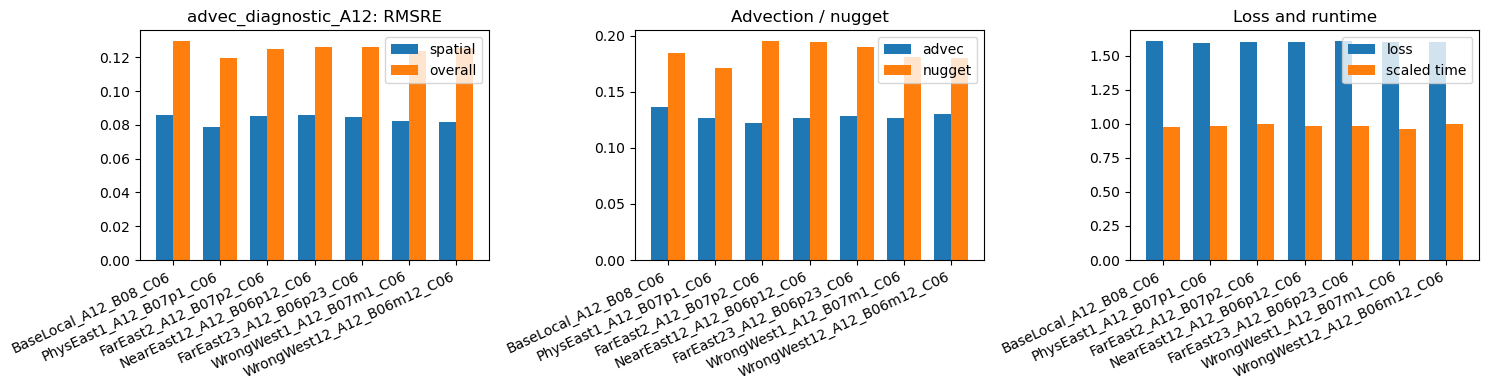

In [9]:
for group, sub in mc_summary.groupby("group", sort=False):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    x = np.arange(len(sub))
    labels = sub["model"].to_list()

    axes[0].bar(x - 0.18, sub["spatial_rmsre_mean"], width=0.36, label="spatial")
    axes[0].bar(x + 0.18, sub["overall_rmsre_mean"], width=0.36, label="overall")
    axes[0].set_title(f"{group}: RMSRE")
    axes[0].set_xticks(x, labels, rotation=25, ha="right")
    axes[0].legend()

    axes[1].bar(x - 0.18, sub["advec_rmsre_mean"], width=0.36, label="advec")
    axes[1].bar(x + 0.18, sub["nugget_re_mean"], width=0.36, label="nugget")
    axes[1].set_title("Advection / nugget")
    axes[1].set_xticks(x, labels, rotation=25, ha="right")
    axes[1].legend()

    axes[2].bar(x - 0.18, sub["loss_mean"], width=0.36, label="loss")
    axes[2].bar(x + 0.18, sub["total_s_mean"] / max(sub["total_s_mean"].max(), 1), width=0.36, label="scaled time")
    axes[2].set_title("Loss and runtime")
    axes[2].set_xticks(x, labels, rotation=25, ha="right")
    axes[2].legend()

    plt.tight_layout()
    plt.show()


## Diagnostic Decision Rule


In [10]:
print("Diagnostic decision rule:")
print("1. +1 east beats base and west controls -> physically aligned upstream signal.")
print("2. +2/+3 east beats +1 and west -> farther directional-sector signal, not physical displacement.")
print("3. east and west both improve similarly -> generic spatial diversity, not advection-specific.")
print("4. none improves advec_lon or uncertainty -> advection band has weak diagnostic value here.")
display(spec_df[["model" if "model" in spec_df.columns else "name"]] if False else spec_df[["limit_A", "limit_B", "limit_C", "advec_cell_offsets", "total_conditioning", "allocation"]])


Diagnostic decision rule:
1. +1 east beats base and west controls -> physically aligned upstream signal.
2. +2/+3 east beats +1 and west -> farther directional-sector signal, not physical displacement.
3. east and west both improve similarly -> generic spatial diversity, not advection-specific.
4. none improves advec_lon or uncertainty -> advection band has weak diagnostic value here.


,limit_A,limit_B,limit_C,advec_cell_offsets,total_conditioning,allocation
advec_diagnostic_A12::BaseLocal_A12_B08_C06,12,8,6,(),28,base local lag-1
advec_diagnostic_A12::PhysEast1_A12_B07p1_C06,12,7,6,"(1,)",28,physical bracket: +1 east
advec_diagnostic_A12::FarEast2_A12_B07p2_C06,12,7,6,"(2,)",28,farther east: +2
advec_diagnostic_A12::NearEast12_A12_B06p12_C06,12,6,6,"(1, 2)",28,"near/far east band: +1,+2"
advec_diagnostic_A12::FarEast23_A12_B06p23_C06,12,6,6,"(2, 3)",28,"far east band: +2,+3"
advec_diagnostic_A12::WrongWest1_A12_B07m1_C06,12,7,6,"(-1,)",28,wrong direction control: -1 west
advec_diagnostic_A12::WrongWest12_A12_B06m12_C06,12,6,6,"(-1, -2)",28,"wrong direction control: -1,-2 west"


## Interpretation

The low-resolution grid has longitude spacing 0.252, so the true upstream displacement 0.126 is half a cell. Because same-location lag-1 is already included in every model, the physically aligned diagnostic offset is +1 east cell. The +2/+3 east models are not physical-displacement models; they test whether farther east-sector information is useful. The west-offset controls test whether any improvement is truly directional rather than just extra nonlocal spatial diversity.
